# 02 — Price Model & Deal Scorer

**Goal of this notebook:** build a model that estimates a fair price for a listing,
then turn that estimate into the product's hero feature — a great / good / bad deal
score. We build it the way a data scientist actually works: start with the dumbest
possible model, measure it, then only add complexity that earns its keep.

**Step 1 — A baseline to beat**

Before any machine learning, we need a reference point. The simplest "model" imaginable:
**ignore every feature and always predict the average price.** It sounds useless — and it
is — but it gives us a number to measure against. If a real model can't beat "just guess
the mean," the model is worthless.

We measure with three standard regression metrics:
- **MAE** (mean absolute error): on average, how many euros are we off? Easy to explain.
- **RMSE** (root mean squared error): like MAE but punishes big misses harder.
- **R²**: what fraction of price variation the model explains. 0 = no better than the mean,
  1 = perfect. A baseline that predicts the mean scores **R² = 0 by definition** — that's
  our floor.

We train on `ml_df` (the cleaned, outlier-free dataset from preprocessing).

In [5]:
import os, sys
from pathlib import Path

# Step up to project root so "from backend import ..." works (same as notebook 01).
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from backend import preprocessing

# Get the ML dataset (cleaned + outliers removed) from our single source of truth.
_, ml_df = preprocessing.run()
print(f"ML dataset: {len(ml_df)} rows")

# Same split the model module uses, so every number in this notebook is comparable.
TARGET = "price_in_euro"
y = ml_df[TARGET].astype(float)
X = ml_df.drop(columns=[TARGET])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# The baseline: predict the mean training price for every listing.
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

mae = mean_absolute_error(y_test, baseline_pred)
rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
r2 = r2_score(y_test, baseline_pred)

print("\n--- Baseline: always predict the mean ---")
print(f"Mean training price : €{y_train.mean():,.0f}")
print(f"MAE                 : €{mae:,.0f}")
print(f"RMSE                : €{rmse:,.0f}")
print(f"R2                  : {r2:.3f}")

ML dataset: 4380 rows

--- Baseline: always predict the mean ---
Mean training price : €183,927
MAE                 : €79,626
RMSE                : €116,428
R2                  : -0.000


**Step 2 — A first real model (and why we reuse `model.py`)**

Now we beat the baseline. Instead of writing model code from scratch in the notebook, we
call `train_model` from `backend/model.py` — the same function the website and the AI
assistant will use later. This is the core habit of the project: **the logic lives in one
module, and everything reuses it.**

`model.py` packages a complete recipe behind one call:
- it selects our evidence-based features (`square_meters`, `bedrooms`, `bathrooms`,
  `floor`, `has_elevator`, `furnishing_status`),
- fills missing values, one-hot encodes the furnishing category, and
- trains on `log(price)` to handle the skew we saw in notebook 01.

The function also lets us **swap the estimator** while keeping that recipe fixed. We start
with the simplest real model — **Linear Regression** — so any improvement we make later is
measured against an honest, simple first attempt.

In [9]:
from sklearn.linear_model import LinearRegression
from backend import model

# Carry the baseline numbers over from Step 1 (still in memory).
baseline = {"MAE": mae, "RMSE": rmse, "R2": r2}

# Same packaged pipeline (features + encoding + log-target); only the estimator changes.
linear_model, linear_metrics = model.train_model(ml_df, estimator=LinearRegression())

print("Features the model uses:", model.FEATURES)
print()
print(f"Baseline (mean) : MAE €{baseline['MAE']:,.0f} | RMSE €{baseline['RMSE']:,.0f} | R2 {baseline['R2']:.3f}")
print(f"Linear model    : MAE €{linear_metrics['MAE']:,.0f} | RMSE €{linear_metrics['RMSE']:,.0f} | R2 {linear_metrics['R2']:.3f}")
print()
print(f"MAE improved by €{baseline['MAE'] - linear_metrics['MAE']:,.0f}")
print(f"R2  improved by {linear_metrics['R2'] - baseline['R2']:.3f}")

Features the model uses: ['square_meters', 'bedrooms', 'bathrooms', 'floor', 'has_elevator', 'furnishing_status']

Baseline (mean) : MAE €79,626 | RMSE €116,428 | R2 -0.000
Linear model    : MAE €59,354 | RMSE €166,946 | R2 -1.056

MAE improved by €20,272
R2  improved by -1.056


**Step 3 — A model that can't blow up: Random Forest**

The linear model failed in an interesting way: a few predictions exploded when we
converted out of log-space. A **Random Forest** can't do that. It predicts by averaging
actual prices from similar listings it saw in training, so its output is always bounded by
the real prices in the data — no extrapolation into the exponential's danger zone.

We change exactly **one thing**: the estimator. Same features, same encoding, same
log-target, same train/test split. That's the whole point of putting the recipe in
`model.py` — comparing models is a one-line change, and the comparison is fair because
everything else is held constant. Random Forest is also `train_model`'s default, so this
is the model the website and the assistant will actually use.

In [12]:
# Random Forest is the default estimator in train_model — no estimator argument needed.
rf_model, rf_metrics = model.train_model(ml_df)

# Compare all three on the same test set.
print(f"{'model':18}{'MAE':>12}{'RMSE':>12}{'R2':>9}")
print("-" * 51)
for name, mtr in [("Baseline (mean)", baseline),
                  ("Linear (log)", linear_metrics),
                  ("Random Forest", rf_metrics)]:
    print(f"{name:18}€{mtr['MAE']:>10,.0f}€{mtr['RMSE']:>10,.0f}{mtr['R2']:>9.3f}")

model                      MAE        RMSE       R2
---------------------------------------------------
Baseline (mean)   €    79,626€   116,428   -0.000
Linear (log)      €    59,354€   166,946   -1.056
Random Forest     €    52,601€    82,191    0.502


**Step 4 — Open the box: is the model sensible?**

R² = 0.50 is a number. Before we trust it, we look at *how* the model is right and wrong,
with two views:

- **Predicted vs actual.** Each listing is a dot: predicted price (x) against true price
  (y). A perfect model puts every dot on the diagonal. We don't expect perfection — we
  expect a cloud that hugs the diagonal, tighter for cheaper homes and looser for
  expensive ones (where data is thin). This shows R²=0.50 as a real shape, not jargon.

- **Feature importance.** A Random Forest can report how much each feature helped. We
  expect `square_meters` to dominate (it had the strongest correlation in notebook 01),
  with bedrooms/bathrooms/floor adding less. If something nonsensical topped the list,
  we'd suspect a leak or a bug. This is a sanity check, not just a chart.

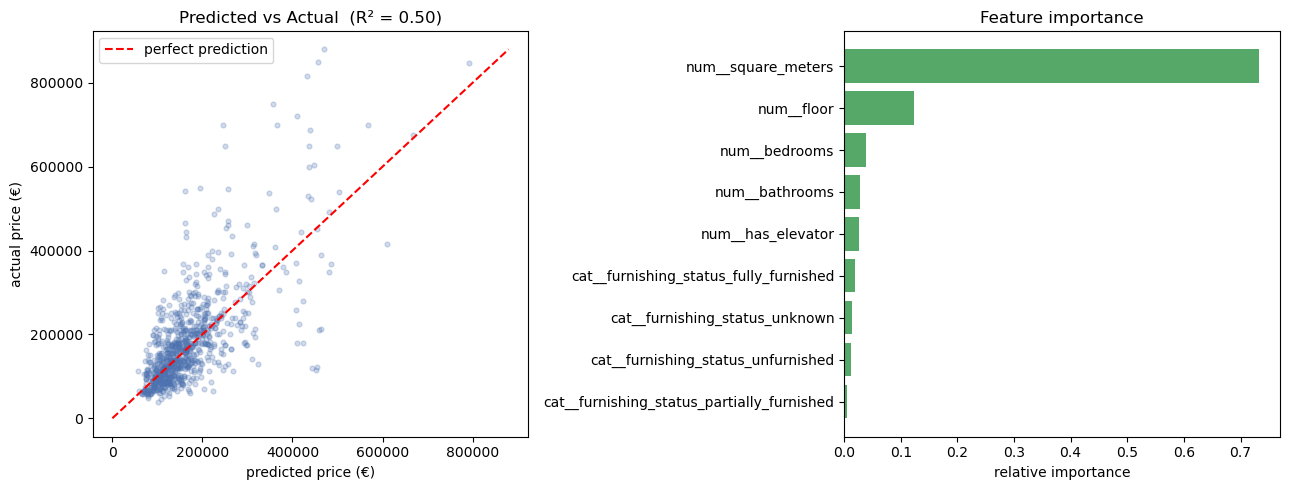

Top features:
  num__square_meters        0.733
  num__floor                0.123
  num__bedrooms             0.039
  num__bathrooms            0.028
  num__has_elevator         0.027
  cat__furnishing_status_fully_furnished 0.019


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from backend import model

# Rebuild the same test split to get predictions to plot.
from sklearn.model_selection import train_test_split
X = model.build_features(ml_df)
y = ml_df[model.TARGET].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: predicted vs actual
axes[0].scatter(preds, y_test, alpha=0.25, s=12, color="#4C72B0")
lims = [0, max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "r--", label="perfect prediction")
axes[0].set_xlabel("predicted price (€)")
axes[0].set_ylabel("actual price (€)")
axes[0].set_title(f"Predicted vs Actual  (R² = {rf_metrics['R2']:.2f})")
axes[0].legend()

# Right: feature importance.
# The trained RF lives inside: TransformedTargetRegressor -> Pipeline -> 'model'.
regressor = rf_model.regressor_              # the fitted inner Pipeline
rf = regressor.named_steps["model"]          # the RandomForestRegressor
feature_names = regressor.named_steps["prep"].get_feature_names_out()

importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
axes[1].barh([feature_names[i] for i in order][::-1],
             [importances[i] for i in order][::-1],
             color="#55A868")
axes[1].set_title("Feature importance")
axes[1].set_xlabel("relative importance")

plt.tight_layout()
plt.show()

print("Top features:")
for i in order[:6]:
    print(f"  {feature_names[i]:25s} {importances[i]:.3f}")

**Step 5 — The hero feature: great / good / bad deals**

This is the product. A price prediction on its own is mildly interesting; what people
actually want to know is **"is this listing a good buy?"** We answer it by comparing each
listing's asking price to what our model thinks it should cost:

> gap = (predicted − listed) / predicted

A positive gap means the listing is **cheaper than predicted** — a potential bargain. We
turn that number into three grades using the thresholds in `model.py`:
- **great** — listed ≥ 15% below prediction
- **good** — listed 5–15% below prediction
- **bad** — fairly priced or overpriced (not a deal)

Two things to check before we trust it:
1. **Are the thresholds sensible for *our* data?** We look at the actual distribution of
   gaps. If almost everything lands in one bucket, the thresholds need tuning.
2. **Do the flagged "great deals" look real?** We eyeball a few — a deal score is only
   useful if a human nods at the examples.

`score_deal` is imported from `model.py` — the *exact* function the website badges and the
AI assistant will call. We're testing the real thing.

Deal grade distribution:
grade
bad      2863
good      839
great     678
Name: count, dtype: int64
grade
bad      65.4 %
good     19.2 %
great    15.5 %
Name: proportion, dtype: object


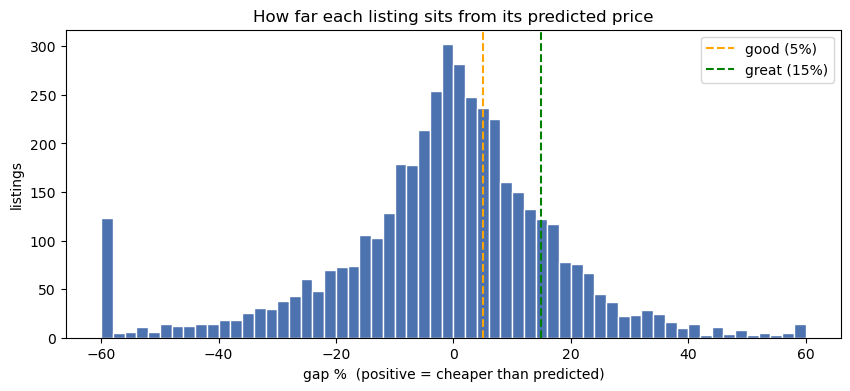


Top 5 'great' deals (biggest gap):
      listing_id  price_in_euro      predicted    gap_pct  square_meters  \
2226        2287       115000.0  452452.330630  74.582958          144.0   
1188        1220       120000.0  442956.486076  72.909303          200.0   
3979        4090       123456.0  454350.815653  72.828045          194.0   
2700        2776        65000.0  223005.867791  70.852785           88.0   
4044        4159        70481.0  204530.015883  65.540021           88.1   

      bedrooms                                    address  
2226       2.0                     Fresk, Tirana, Albania  
1188       3.0  Rruga Petro Nini Luarasi, Tiranë, Albania  
3979       3.0    rr. muhamet gjollesha, Tiranë, Shqipëri  
2700       2.0          Rruga e Durrësit, Tirana, Albania  
4044       2.0              Bulevardi Blu, Kamez, Albania  


In [18]:
from backend import model

# Predict on EVERY listing, then score each against its asking price.
work = ml_df.copy()
work["predicted"] = rf_model.predict(model.build_features(work))
work["gap_pct"] = (work["predicted"] - work["price_in_euro"]) / work["predicted"] * 100
work["grade"] = [
    model.score_deal(p, a)["grade"]
    for p, a in zip(work["predicted"], work["price_in_euro"])
]

# 1. How do listings split across the three grades?
print("Deal grade distribution:")
print(work["grade"].value_counts())
print((work["grade"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

# 2. Visualize the gap distribution with the thresholds marked.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(work["gap_pct"].clip(-60, 60), bins=60, color="#4C72B0", edgecolor="white")
plt.axvline(model.GOOD_DEAL_GAP * 100, color="orange", linestyle="--", label="good (5%)")
plt.axvline(model.GREAT_DEAL_GAP * 100, color="green", linestyle="--", label="great (15%)")
plt.xlabel("gap %  (positive = cheaper than predicted)")
plt.ylabel("listings")
plt.title("How far each listing sits from its predicted price")
plt.legend()
plt.show()

# 3. Do the top "great deals" look believable?
cols = ["listing_id", "price_in_euro", "predicted", "gap_pct", "square_meters",
        "bedrooms", "address"]
print("\nTop 5 'great' deals (biggest gap):")
print(work[work["grade"] == "great"].sort_values("gap_pct", ascending=False)[cols].head())

**Step 6 — Save the model for the web app**

The model only matters if other parts of the project can use it. We save the entire
trained pipeline — preprocessing, encoding, log-transform, and the Random Forest — as a
single file with `joblib`. Because the whole pipeline is saved together, whatever loads it
in Week 2 gets the identical behaviour we validated here: no risk of the website
preprocessing data differently from how the model was trained.

We save through `model.save_model()` (the same helper the smoke test uses), writing to
`models/model.joblib`. After this, the website and the AI assistant load *this* file and
call `predict_price` and `score_deal` on it — the functions we've been exercising all along.

That closes the data-and-model phase: raw JSON → clean data → trained model → a working
deal scorer, all behind reusable functions.

In [21]:
from backend import model

# Save the Random Forest pipeline we settled on.
model.save_model(rf_model)
print(f"Saved model -> {model.MODEL_PATH}")

# Confirm it reloads and behaves identically to the in-memory model.
reloaded = model.load_model()
sample = ml_df.iloc[0].to_dict()
pred_mem = model.predict_price(rf_model, sample)
pred_disk = model.predict_price(reloaded, sample)

print(f"\nSample listing: listed €{sample['price_in_euro']:,.0f}")
print(f"Prediction (in-memory) : €{pred_mem:,.0f}")
print(f"Prediction (from disk) : €{pred_disk:,.0f}")
print(f"Match: {round(pred_mem) == round(pred_disk)}")

deal = model.score_deal(pred_disk, sample["price_in_euro"])
print(f"Deal grade for this listing: {deal['grade']} ({deal['gap_pct']:+.1f}% vs predicted)")

Saved model -> models\model.joblib

Sample listing: listed €400,000
Prediction (in-memory) : €416,007
Prediction (from disk) : €416,007
Match: True
Deal grade for this listing: bad (+3.8% vs predicted)
